# Databento Tick-Level Market Data Exploration

This notebook provides interactive exploration and visualization of the Databento Binary Representation (DBN) data extracted from your downloaded ZIP archives. 

We will:
1. **Locate & Extract** tick data on-the-fly from the zip archives.
2. **Parse and clean** the datasets (top of book `tbbo` and transaction `trades` schemas).
3. **Analyze Microstructure Statistics** such as bid-ask spreads, trade sizes, and volume profiles.
4. **Visualize Intraday Price Channels** with BBO (Best Bid/Offer) shading.
5. **Compare Cross-Asset Returns** (MSFT, GOOGL, TSLA, SPY, QQQ) on a specific trading day.

In [1]:
import os
import glob
import json
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import databento as db

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)
plt.rcParams["figure.dpi"] = 100

## 1. Dynamic Archive Discovery
We scan the workspace for files matching `EQUS-*.zip` and inspect their `metadata.json` to identify which contains the `tbbo` (top of book) schema and which contains `trades` (transaction records).

In [2]:
def find_zip_for_schema(schema, workspace_dir="."):
    zip_files = glob.glob(os.path.join(workspace_dir, "EQUS-*.zip"))
    for zp in zip_files:
        try:
            with zipfile.ZipFile(zp, 'r') as zf:
                if 'metadata.json' in zf.namelist():
                    meta = json.loads(zf.read('metadata.json').decode('utf-8'))
                    if meta.get('query', {}).get('schema') == schema:
                        return zp
        except Exception:
            continue
    return None

tbbo_zip = find_zip_for_schema("tbbo")
trades_zip = find_zip_for_schema("trades")

print(f"TBBO Zip found: {tbbo_zip}")
print(f"Trades Zip found: {trades_zip}")

TBBO Zip found: ./EQUS-20260622-NMGRK8ATQW.zip
Trades Zip found: ./EQUS-20260622-W9UG4SAVR5.zip


## 2. Load & Clean Databento Data
Let's write a utility to extract a specific date's file and load it as a pandas DataFrame using the `databento` library.

In [3]:
def load_databento_day(schema, date, workspace_dir=".", extract_dir="databento_data"):
    os.makedirs(extract_dir, exist_ok=True)
    filename = f"equs-mini-{date.replace('-', '')}.{schema}.dbn.zst"
    dest_path = os.path.join(extract_dir, filename)
    
    if not os.path.exists(dest_path):
        zip_path = find_zip_for_schema(schema, workspace_dir)
        if not zip_path:
            raise FileNotFoundError(f"Could not find zip archive for {schema}")
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extract(filename, extract_dir)
            
    store = db.DBNStore.from_file(dest_path)
    df = store.to_df()
    
    # Timezone conversion: UTC to US/Eastern
    if df.index.tz is None:
        df.index = pd.to_datetime(df.index, unit='ns').tz_localize('UTC')
    df.index = df.index.tz_convert('US/Eastern')
    
    return df

## 3. Microstructure Analysis for a Single Symbol
Let's load the `tbbo` schema for a sample date (e.g. `2025-12-22`, a standard Monday) and analyze `TSLA` (Tesla).

In [4]:
sample_date = "2025-12-22"
symbol = "TSLA"

df_full = load_databento_day("tbbo", sample_date)
df_tsla = df_full[df_full['symbol'] == symbol].copy()

df_tsla['spread'] = df_tsla['ask_px_00'] - df_tsla['bid_px_00']
df_tsla['mid_price'] = (df_tsla['ask_px_00'] + df_tsla['bid_px_00']) / 2.0
df_tsla['spread_bps'] = (df_tsla['spread'] / df_tsla['mid_price']) * 10000

print(f"Loaded {len(df_tsla):,} ticks for {symbol} on {sample_date}")
print(f"Average Transaction Price: ${df_tsla['price'].mean():.2f}")
print(f"Average Bid-Ask Spread: ${df_tsla['spread'].mean()*100:.2f} cents ({df_tsla['spread_bps'].mean():.2f} bps)")
print(f"Total Trading Volume: {df_tsla['size'].sum():,} shares")

Loaded 25,780 ticks for TSLA on 2025-12-22
Average Transaction Price: $492.41
Average Bid-Ask Spread: $48.10 cents (9.78 bps)
Total Trading Volume: 1,022,903 shares


### Intraday Microstructure Plot
We plot the trade prices along with the best bid and ask quotes to visualize the bid-ask channel, the spread expansion/contraction, and trading volume intensity.

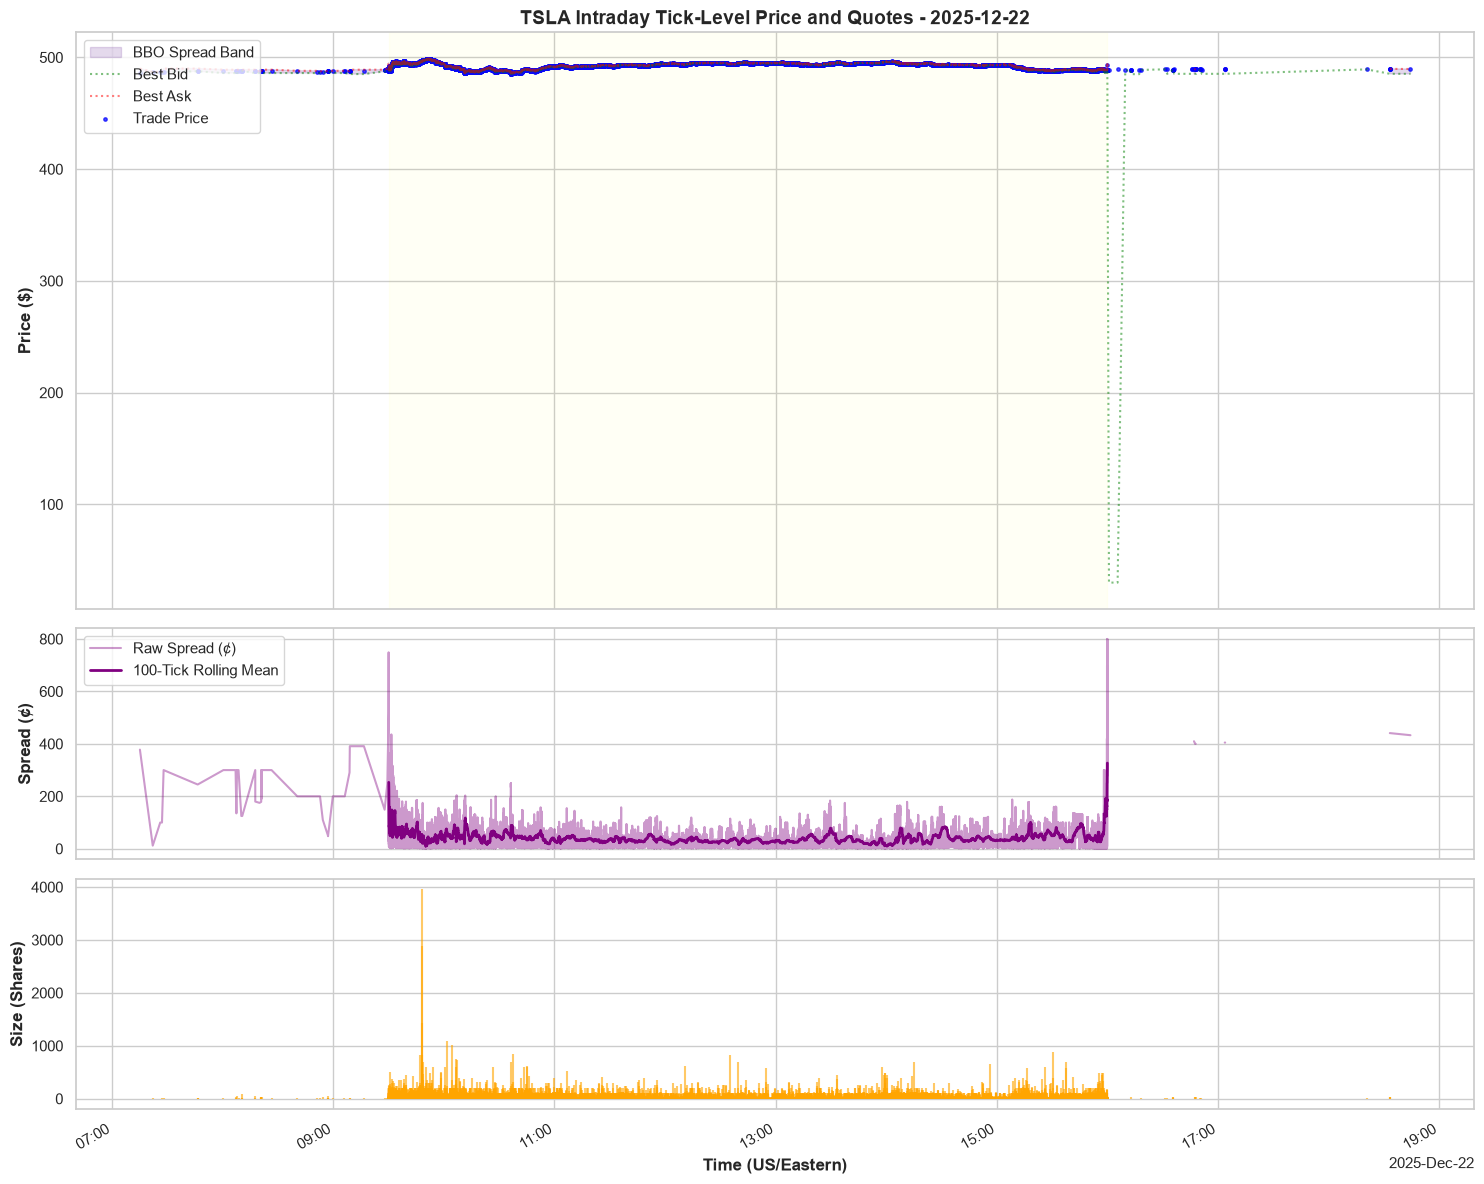

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [2.5, 1, 1]})

# 1. Price Channel
axes[0].fill_between(df_tsla.index, df_tsla['bid_px_00'], df_tsla['ask_px_00'], color='indigo', alpha=0.15, label='BBO Spread Band')
axes[0].plot(df_tsla.index, df_tsla['bid_px_00'], color='green', linestyle=':', alpha=0.5, label='Best Bid')
axes[0].plot(df_tsla.index, df_tsla['ask_px_00'], color='red', linestyle=':', alpha=0.5, label='Best Ask')
axes[0].scatter(df_tsla.index, df_tsla['price'], color='blue', s=6, alpha=0.7, label='Trade Price')
axes[0].set_ylabel("Price ($)", fontsize=12, fontweight='bold')
axes[0].set_title(f"{symbol} Intraday Tick-Level Price and Quotes - {sample_date}", fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')

# Highlight Regular Trading Hours (RTH)
rth_start = pd.Timestamp(f"{sample_date} 09:30:00", tz='US/Eastern')
rth_end = pd.Timestamp(f"{sample_date} 16:00:00", tz='US/Eastern')
axes[0].axvspan(rth_start, rth_end, color='yellow', alpha=0.04, label='RTH')

# 2. Spread
axes[1].plot(df_tsla.index, df_tsla['spread'] * 100, color='purple', alpha=0.4, label='Raw Spread (¢)')
axes[1].plot(df_tsla.index, (df_tsla['spread'] * 100).rolling(window=100).mean(), color='purple', linewidth=2, label='100-Tick Rolling Mean')
axes[1].set_ylabel("Spread (¢)", fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')

# 3. Volume Profile
axes[2].vlines(df_tsla.index, 0, df_tsla['size'], color='orange', alpha=0.6, label='Trade Size')
axes[2].set_ylabel("Size (Shares)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Time (US/Eastern)", fontsize=12, fontweight='bold')

locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
formatter = mdates.ConciseDateFormatter(locator, tz=df_tsla.index.tz)
axes[2].xaxis.set_major_locator(locator)
axes[2].xaxis.set_major_formatter(formatter)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. Cross-Asset Return Correlation & Volatility Comparison
Let's compare the performance of all 5 assets: `MSFT`, `GOOGL`, `TSLA`, `SPY`, and `QQQ`. We will resample their tick data to 5-minute intervals and calculate cumulative returns.

In [6]:
symbols = ['MSFT', 'GOOGL', 'TSLA', 'SPY', 'QQQ']
resampled_dfs = []

for sym in symbols:
    df_sym = df_full[df_full['symbol'] == sym].copy()
    # Resample to 5-minute intervals taking the last trade price (OHLCV Close)
    close_5m = df_sym['price'].resample('5min').last().ffill()
    close_5m.name = sym
    resampled_dfs.append(close_5m)

# Combine into a single Multi-Asset DataFrame
df_assets = pd.concat(resampled_dfs, axis=1).ffill().dropna()

# Filter to Regular Trading Hours
df_assets = df_assets.between_time("09:30", "16:00")

# Compute Cumulative Returns starting from the market open (09:30)
df_returns = (df_assets / df_assets.iloc[0] - 1.0) * 100.0

print("Sample of 5-minute Resampled Prices:")
print(df_assets.head())

Sample of 5-minute Resampled Prices:
                             MSFT    GOOGL     TSLA     SPY     QQQ
ts_recv                                                            
2025-12-22 09:30:00-05:00  486.21  306.720  494.505  683.65  619.51
2025-12-22 09:35:00-05:00  483.92  305.860  495.010  683.29  619.33
2025-12-22 09:40:00-05:00  483.44  306.825  493.930  683.24  619.26
2025-12-22 09:45:00-05:00  483.32  306.960  497.710  683.39  619.85
2025-12-22 09:50:00-05:00  484.46  306.570  496.740  683.99  620.69


/var/folders/k6/vh9m1qvx7s37pn22yfvrbc3c0000gn/T/ipykernel_41173/2079103956.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_assets = pd.concat(resampled_dfs, axis=1).ffill().dropna()


### Plotting Relative Performance & Correlation Matrix

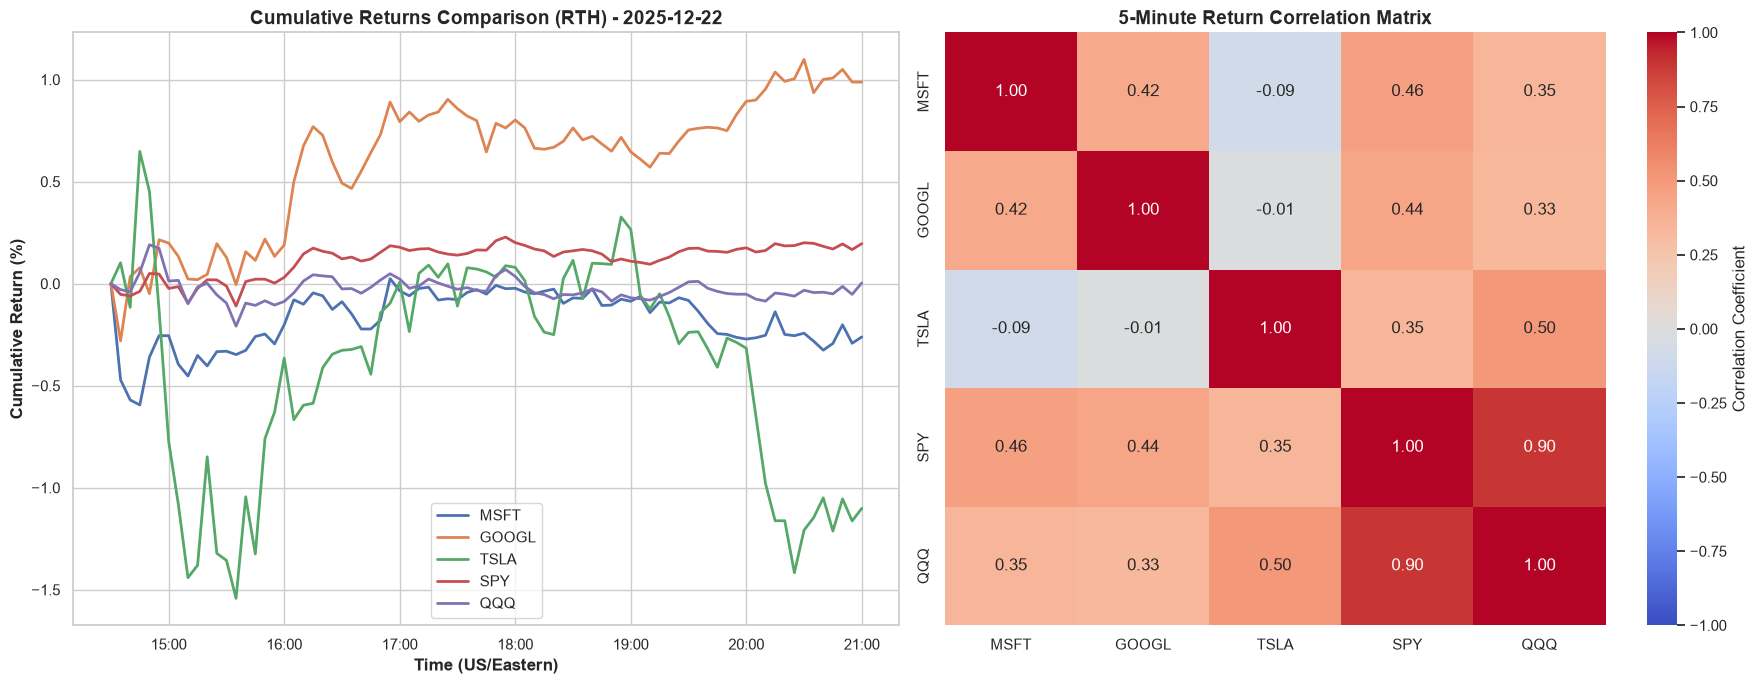

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Performance chart
for sym in symbols:
    axes[0].plot(df_returns.index, df_returns[sym], label=sym, linewidth=2)
axes[0].set_title(f"Cumulative Returns Comparison (RTH) - {sample_date}", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Cumulative Return (%)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Time (US/Eastern)", fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[0].legend(fontsize=11)

# 2. Correlation Matrix
corr_matrix = df_assets.pct_change().dropna().corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[1], cbar_kws={'label': 'Correlation Coefficient'})
axes[1].set_title("5-Minute Return Correlation Matrix", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()